In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[15:19:13] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=166364;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=451242;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

# **Mass-Size relation to the fractal dimension**
This Notebook explores the connection of the mass and size scaling properties with the fractal dimension. To this end, the following steps are carried out:

1. Calculate the fractal dimension of the biggest structures at each column density thresholds
2. Assess the trend compared with the general trend (when not divided into substructures)
3. Calculate mass and size of the single sub-structures
4. Assess M-L-D scaling properties 

### **Outlook**
1. Low Band Mass is too high! -> check total mass (seems fine for now. Orion B is really good, Orion A a bit off). Yet still not enough small cores...
2. Very few cores found, why? I think the issue is in this code, specifically in how the structures are found (mask)!
3. Trend doesn't make sense...
4. Save the regions in pickle again cause it takes too long

In [2]:
# Orion A

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 8.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

# Orion B

# Minkowski
results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

KeyboardInterrupt: 

In [ ]:
import scipy.ndimage as ndimage
from skimage.measure import perimeter
import numpy as np

import pickle 

def pca_major_axis(region_coords):
    """
    Computes the major axis length of a structure using PCA.
    The major axis is the square root of the largest eigenvalue of the covariance matrix.
    """
    if len(region_coords) < 2:
        return 0  # If only one pixel, size is zero

    # Center the coordinates
    centered_coords = region_coords - np.mean(region_coords, axis=0)

    # Compute covariance matrix and its eigenvalues
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)

    # The largest eigenvalue corresponds to the major axis squared
    major_axis = 2 * np.sqrt(np.max(eigenvalues))  # Factor 2 to approximate full length

    return major_axis

def calculate_mass_and_size(region_mask, M_H2, pc_per_px):
    """
    Calculate the mass and the major axis of a structure using PCA.
    - Mass: Summed pixel values converted to solar masses.
    - Size: Major axis computed from PCA eigenvalues.
    """
    # Compute total mass
    mass = np.sum(M_H2[region_mask]) # * cm2_per_px 

    # Find structure coordinates
    region_coords = np.column_stack(np.where(region_mask))

    if len(region_coords) == 0:
        return mass, 0  # If no region is found, return zero size

    # Compute the major axis length using PCA
    major_axis_length = pca_major_axis(region_coords)

    # Convert size to parsecs
    size_parsecs = major_axis_length * pc_per_px

    return mass, size_parsecs

def compute_fractal_dimension(region_mask):
    """
    Compute the fractal dimension of a binary region using the Perimeter-Area relation.
    
    Parameters:
        region_mask (ndarray): Boolean mask of the structure.
        
    Returns:
        float: Estimated fractal dimension.
    """
    area = np.sum(region_mask)
    
    # Compute perimeter using dilation technique
    mask_perimeter = perimeter(region_mask)

    if area > 0 and mask_perimeter > 0:
        return 2*(np.log10(mask_perimeter) / np.log10(area))
    return None  # Invalid case (avoid division errors)

def track_largest_regions_NEW(N_H2, M_H2, thresholds, pc_per_px, num_top_regions=None, min_region_size_px=50):
    """
    Extract regions at each threshold and compute their properties.
    """
    regions = {}

    for threshold in thresholds:
        mask = N_H2 >= threshold  
        labeled_regions, num_features = ndimage.label(mask)

        if num_features == 0:
            print(f"[{threshold}] No regions found.")
            continue

        region_sizes = {
            region_id: np.sum(labeled_regions == region_id)
            for region_id in range(1, num_features + 1)
        }

        # Filter by size or pick top N
        region_ids = sorted(region_sizes, key=region_sizes.get, reverse=True)
        if num_top_regions is not None:
            region_ids = region_ids[:num_top_regions]

        saved_count = 0
        for region_id in region_ids:
            size_px = region_sizes[region_id]
            if size_px < min_region_size_px:
                continue

            region_mask = labeled_regions == region_id
            fractal_dim = compute_fractal_dimension(region_mask)
            mass, size = calculate_mass_and_size(region_mask, M_H2, pc_per_px)

            region_key = f"{threshold}_{region_id}"
            regions[region_key] = {
                "threshold": threshold,
                "fractal_dimension": fractal_dim,
                "mass": mass,
                "size": size,
                "region_mask": region_mask
            }
            saved_count += 1

        print(f"[{threshold}] Found {num_features} regions, saved {saved_count}.")

    return regions

[2.4999999999999995e+21] Found 801 regions, saved 15.
[2.5906544706295043e+21] Found 764 regions, saved 15.
[2.6845962344770563e+21] Found 635 regions, saved 15.
[2.781944494673271e+21] Found 630 regions, saved 15.
[2.88282277686738e+21] Found 525 regions, saved 15.
[2.987359085969617e+21] Found 528 regions, saved 15.
[3.095686068577144e+21] Found 472 regions, saved 15.
[3.2079411812899425e+21] Found 448 regions, saved 15.
[3.3242668651301144e+21] Found 457 regions, saved 15.
[3.4448107262859726e+21] Found 407 regions, saved 15.
[3.569725723410091e+21] Found 375 regions, saved 15.
[3.6991703617093994e+21] Found 392 regions, saved 15.
[3.833308894073048e+21] Found 404 regions, saved 15.
[3.972311529493674e+21] Found 358 regions, saved 15.
[4.1163546490463993e+21] Found 333 regions, saved 15.
[4.2656210296994414e+21] Found 324 regions, saved 15.
[4.4203000762408365e+21] Found 275 regions, saved 15.
[4.5805880616149063e+21] Found 274 regions, saved 15.
[4.746688375973919e+21] Found 285 re

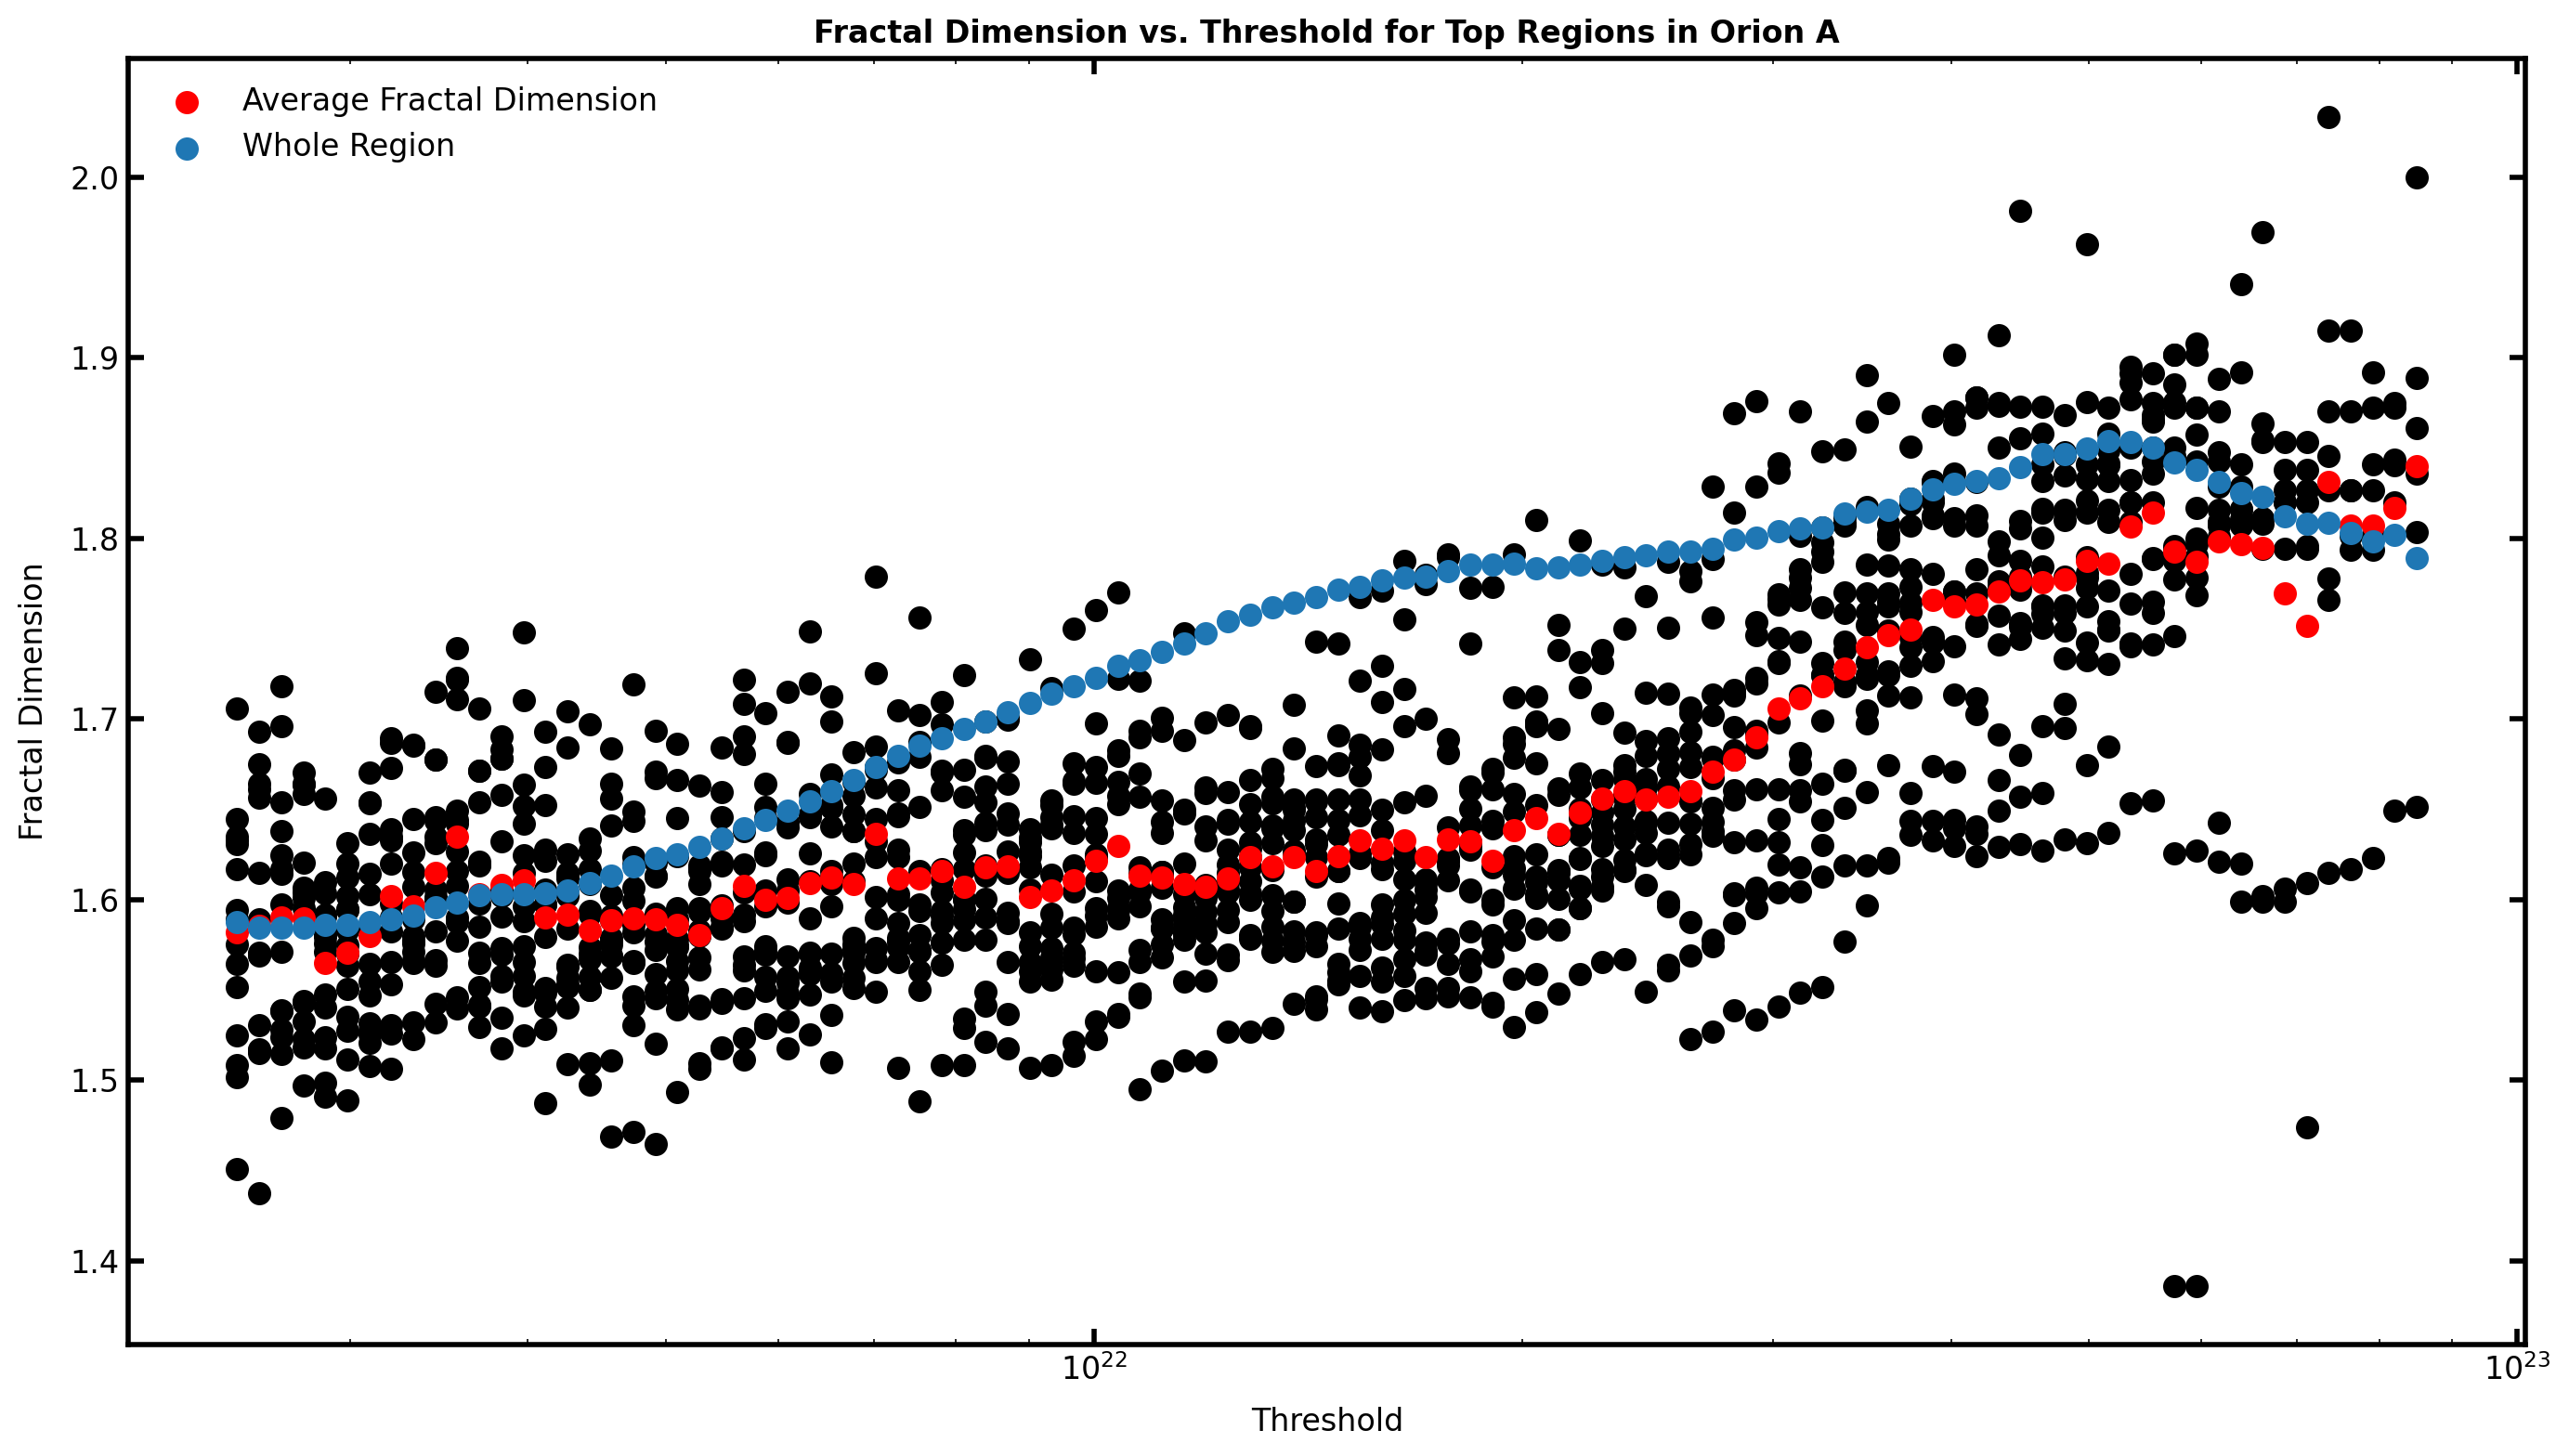

In [ ]:
# Dendograms-like approach to retrieve regions
pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi # conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OA = convert_to_mass(N_H2_OA)

thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100) 

if os.path.exists("top_regions_data_OA.pkl"):
    top_regions_data_OA = load_regions_from_pickle("top_regions_data_OA.pkl")
else:
    top_regions_data_OA = track_largest_regions_NEW(N_H2_OA, M_H2_OA, thresholds, pc_per_px, num_top_regions=15, min_region_size_px=10)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OA.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OA.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OA["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion A", fontweight='bold')
plt.legend()
plt.show()

[2.4999999999999995e+21] Found 788 regions, saved 15.
[2.5906544706295043e+21] Found 692 regions, saved 15.
[2.6845962344770563e+21] Found 695 regions, saved 15.
[2.781944494673271e+21] Found 662 regions, saved 15.
[2.88282277686738e+21] Found 592 regions, saved 15.
[2.987359085969617e+21] Found 514 regions, saved 15.
[3.095686068577144e+21] Found 532 regions, saved 15.
[3.2079411812899425e+21] Found 537 regions, saved 15.
[3.3242668651301144e+21] Found 508 regions, saved 15.
[3.4448107262859726e+21] Found 485 regions, saved 15.
[3.569725723410091e+21] Found 422 regions, saved 15.
[3.6991703617093994e+21] Found 420 regions, saved 15.
[3.833308894073048e+21] Found 393 regions, saved 15.
[3.972311529493674e+21] Found 352 regions, saved 15.
[4.1163546490463993e+21] Found 326 regions, saved 15.
[4.2656210296994414e+21] Found 284 regions, saved 15.
[4.4203000762408365e+21] Found 256 regions, saved 15.
[4.5805880616149063e+21] Found 258 regions, saved 15.
[4.746688375973919e+21] Found 232 re

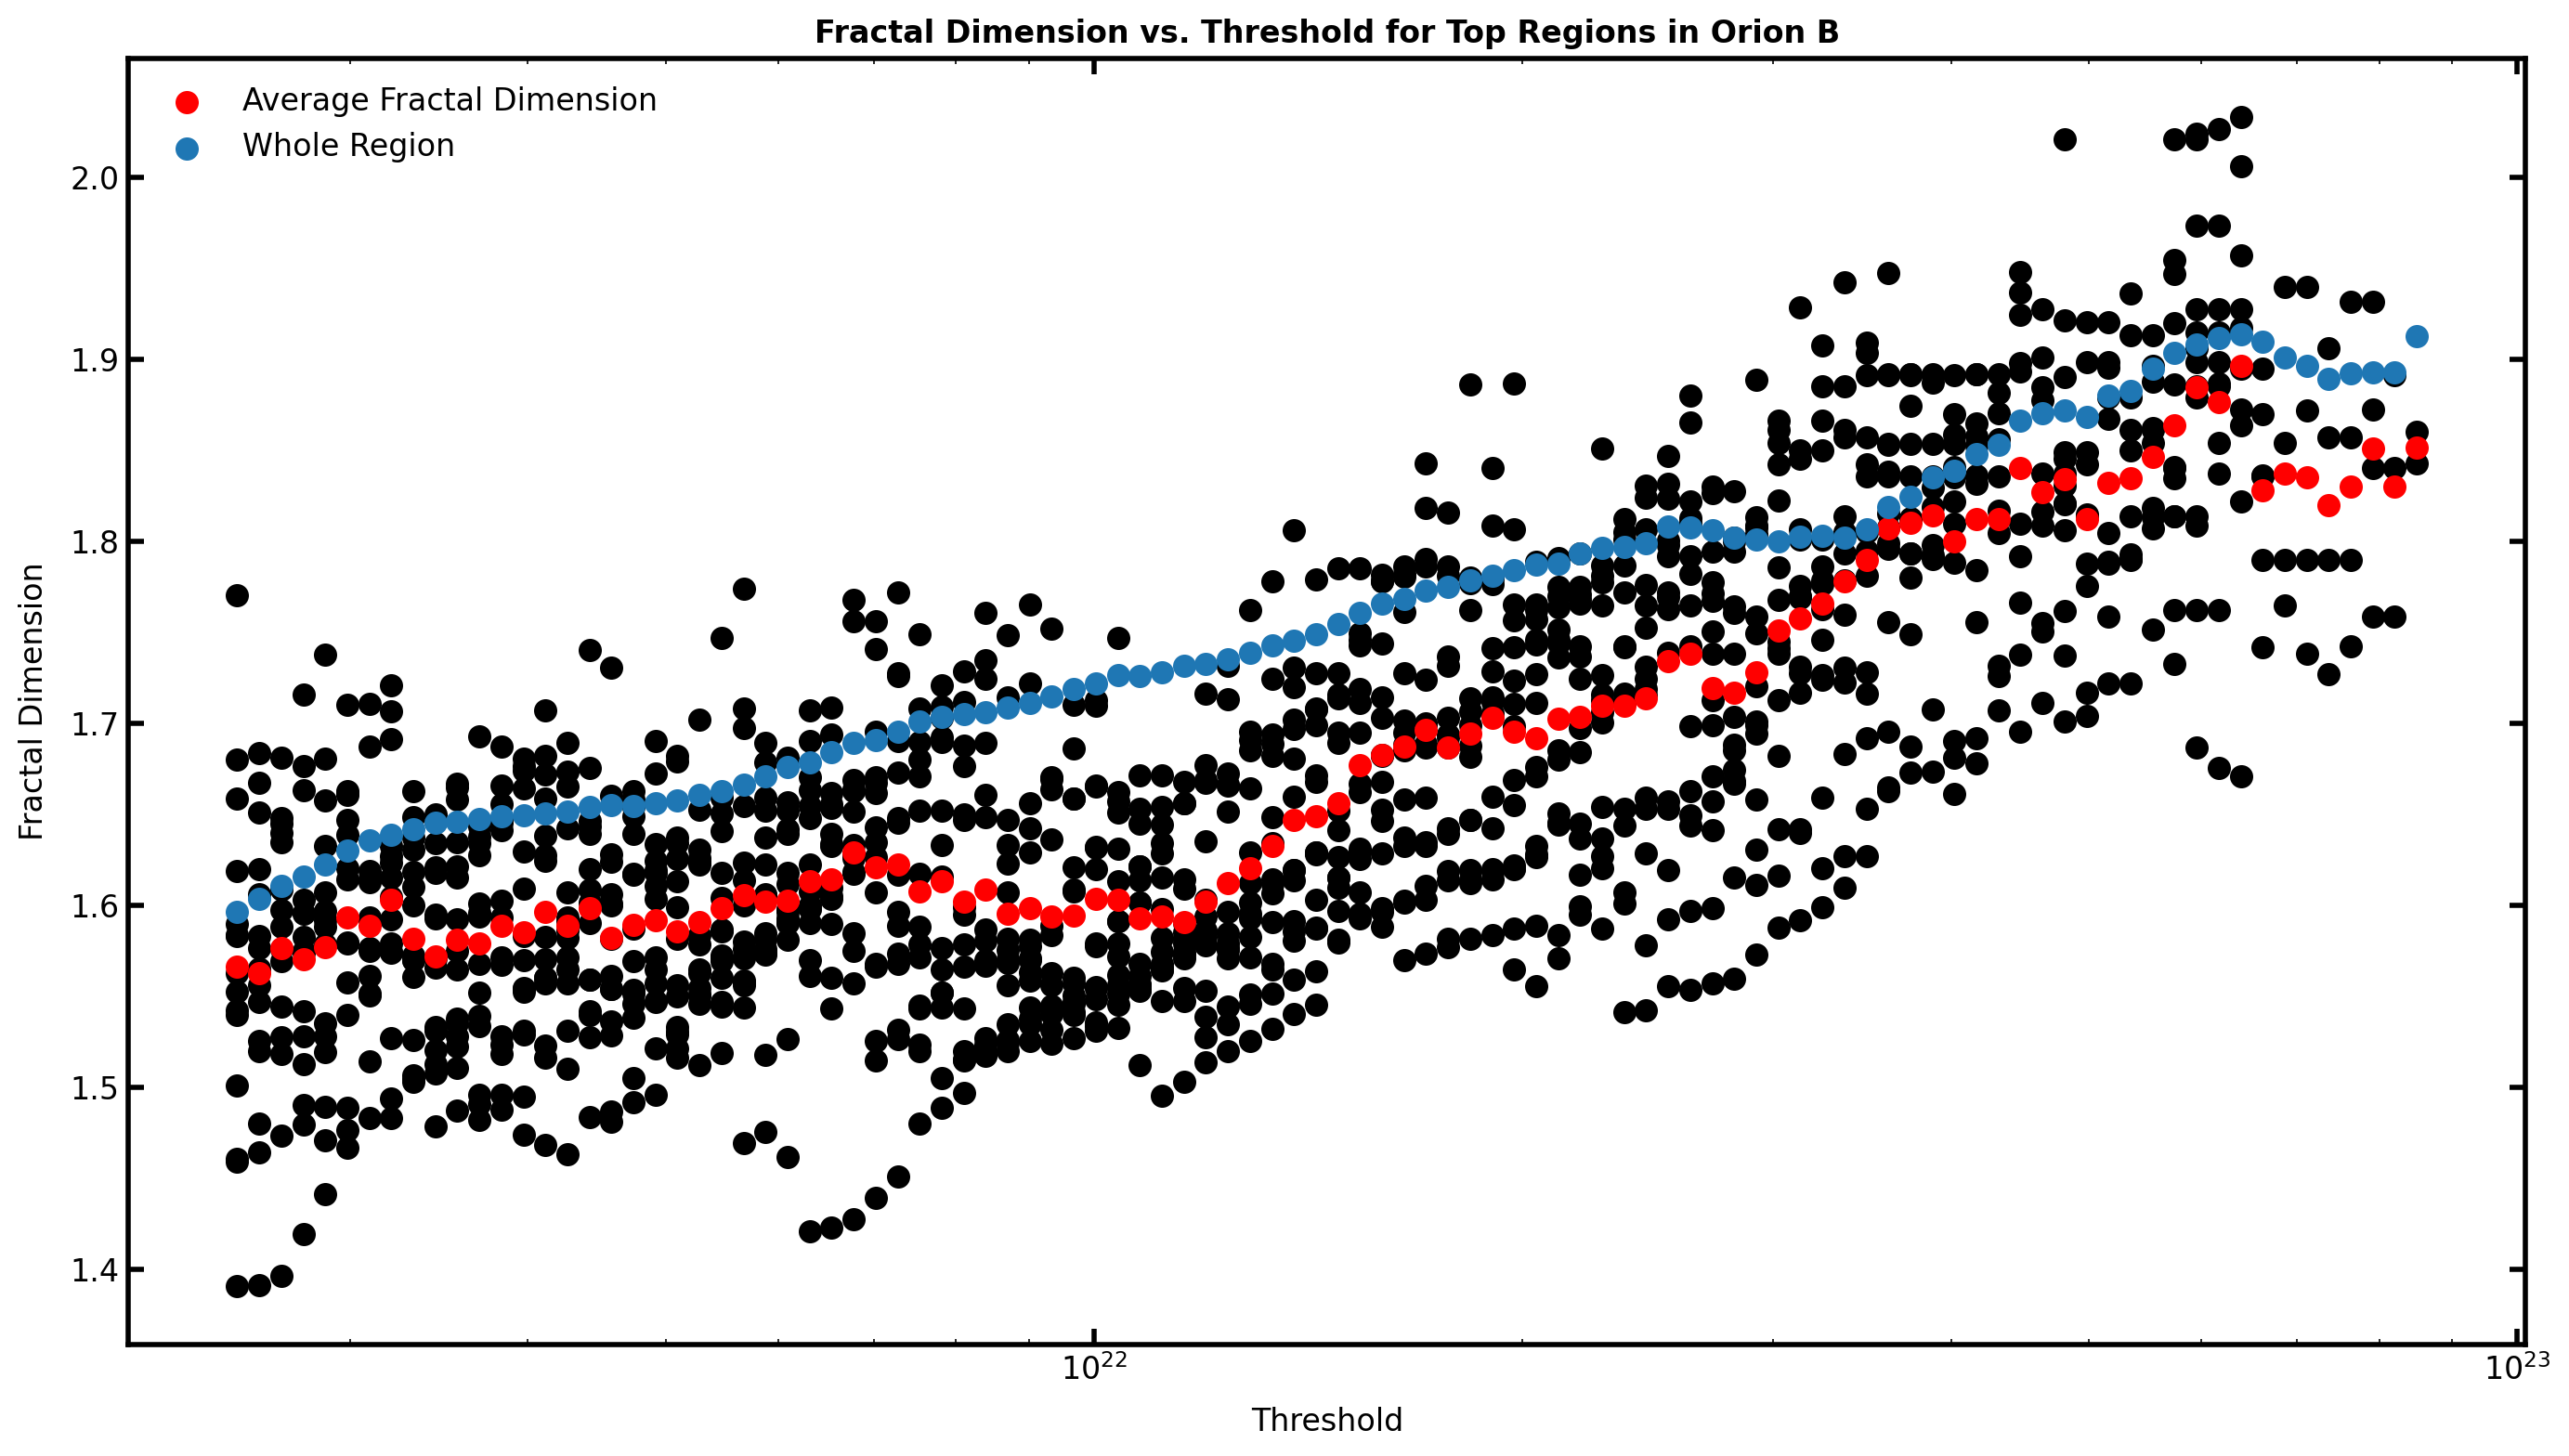

In [ ]:
# Dendograms-like approach to retrieve regions

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OB = convert_to_mass(N_H2_OB)

thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100) 

if os.path.exists("top_regions_data_OB.pkl"):
    top_regions_data_OB = load_regions_from_pickle("top_regions_data_OB.pkl")
else:
    top_regions_data_OB = track_largest_regions_NEW(N_H2_OB, M_H2_OB, thresholds, pc_per_px, num_top_regions=15, min_region_size_px=10)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OB.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OB.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OB["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion B", fontweight='bold')
plt.legend()
plt.show()

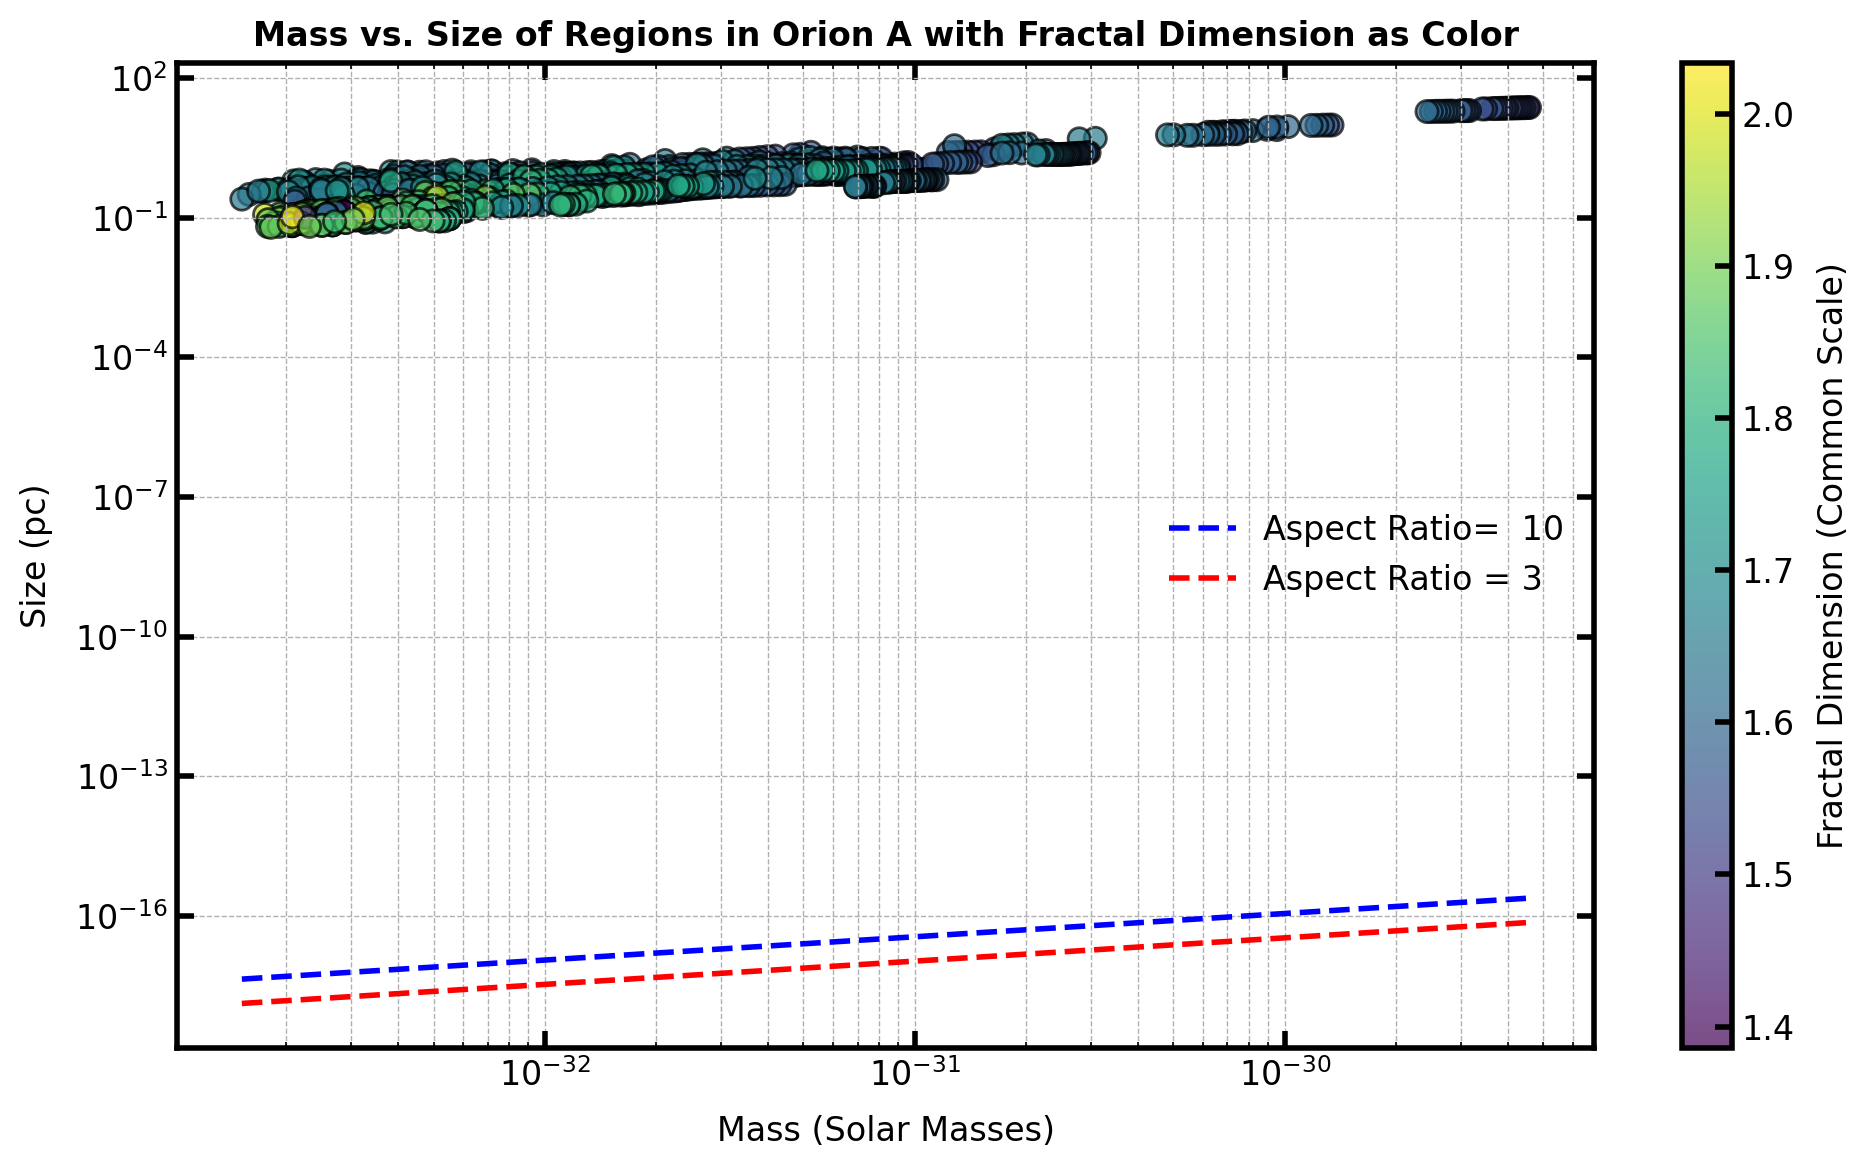

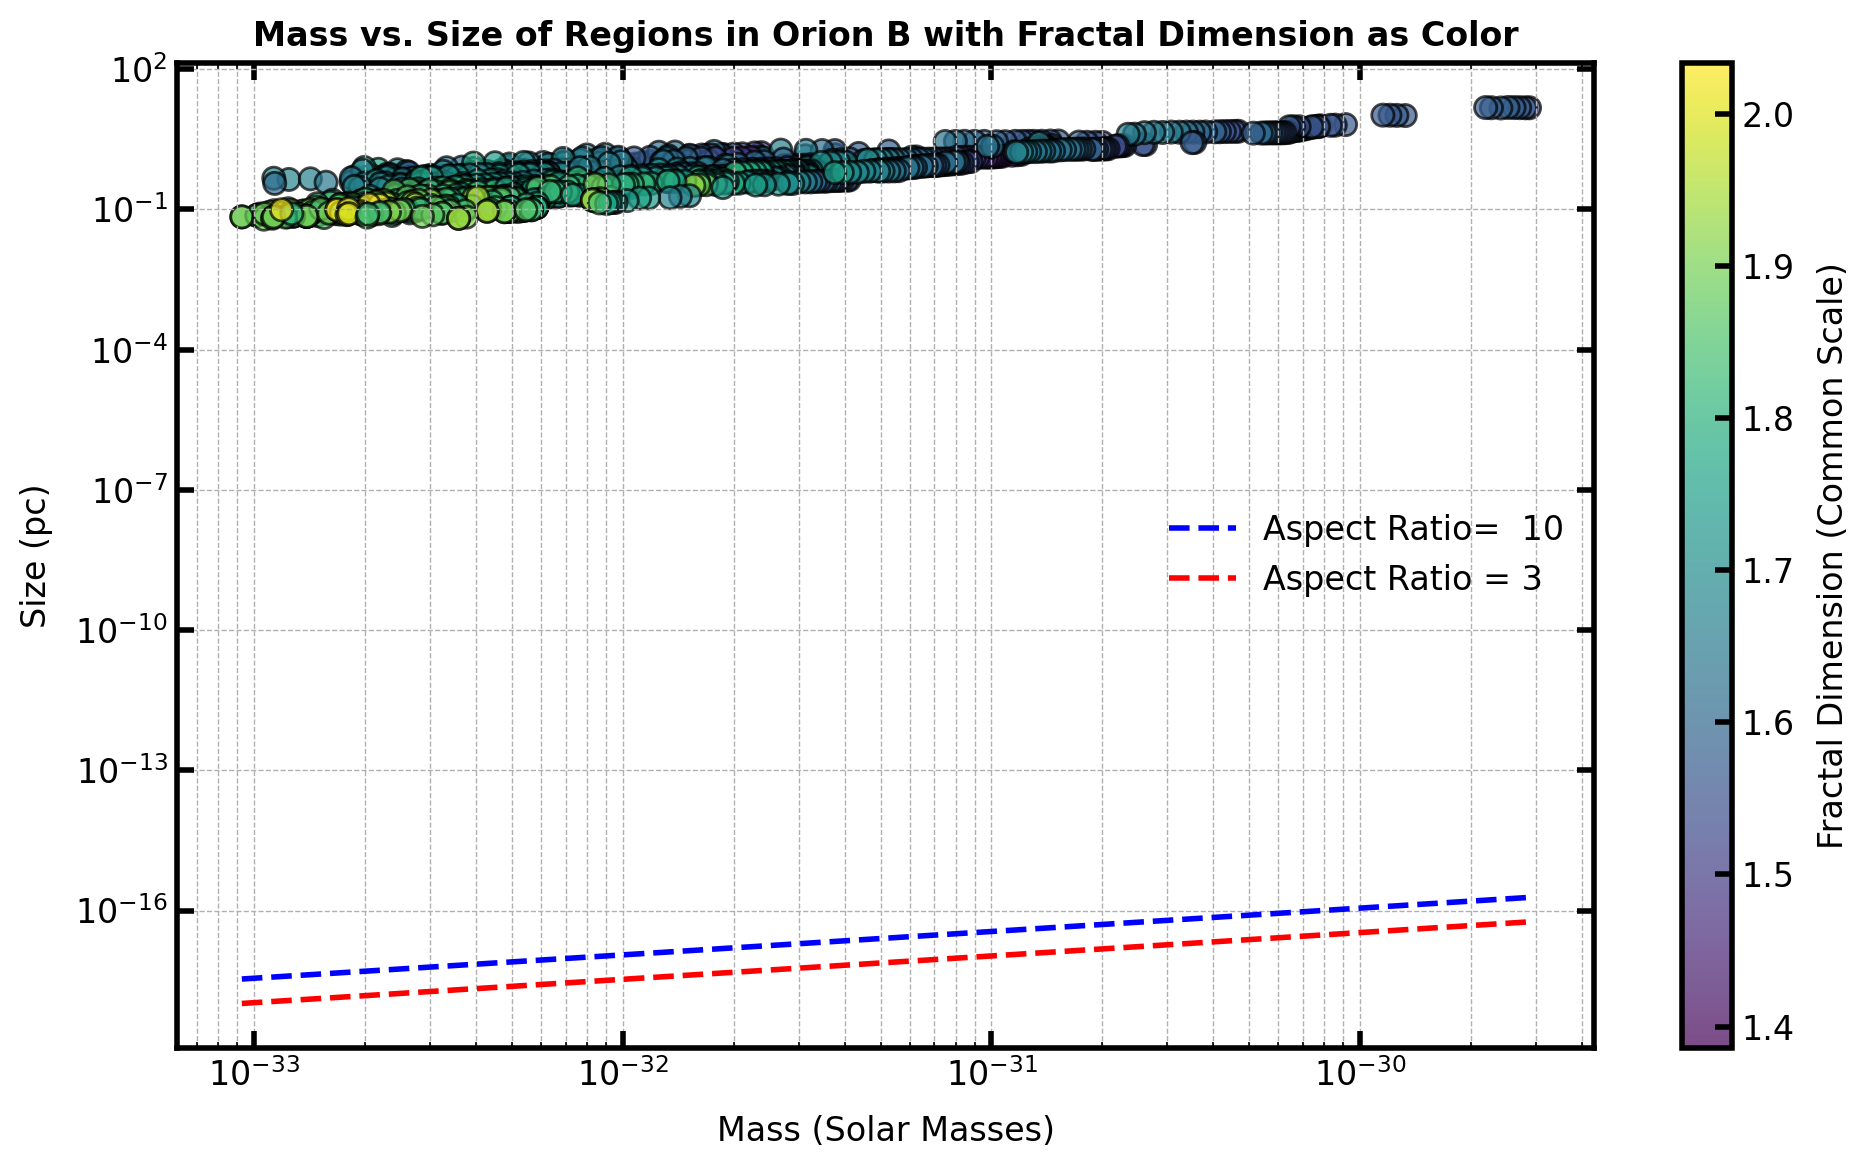

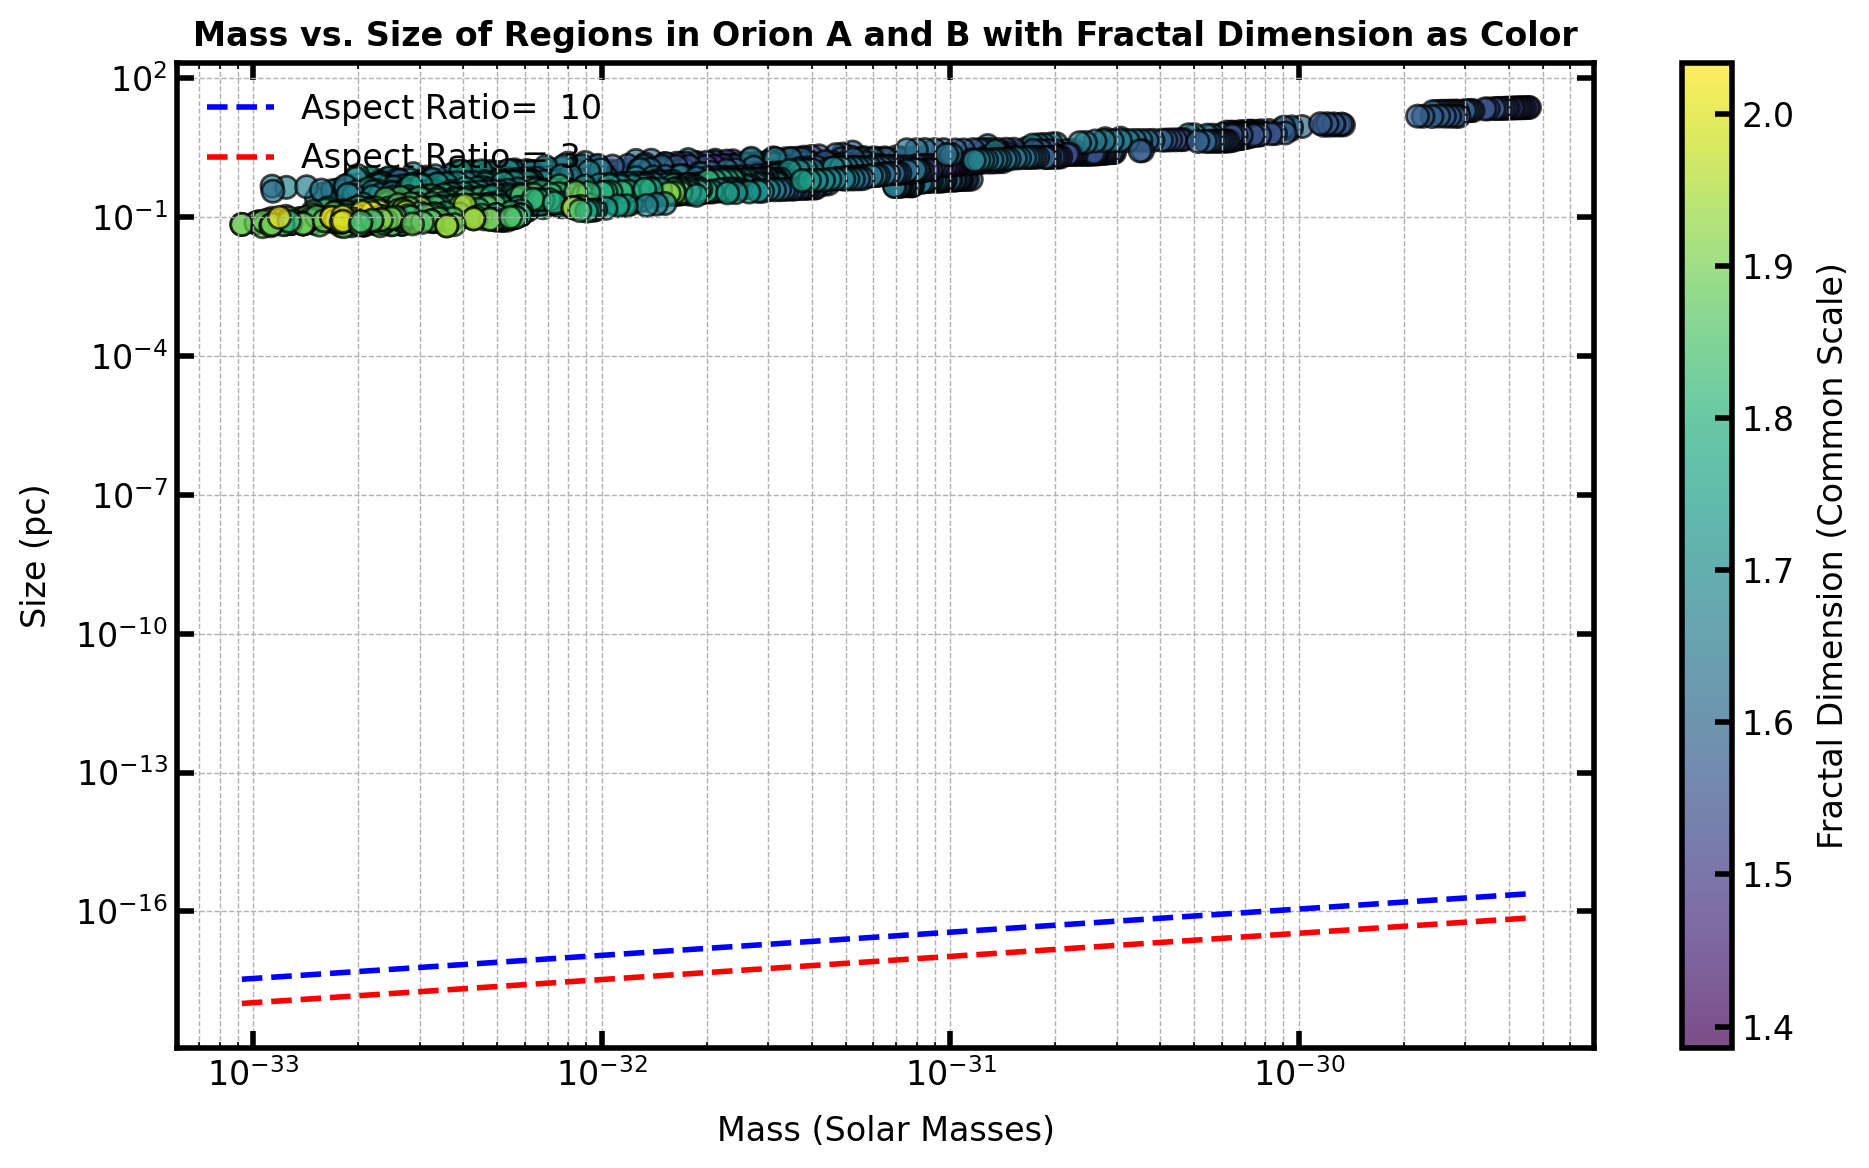

In [ ]:
# Extract fractal dimensions, sizes, and masses for Orion A and B
fractal_dims_OA = [region_data["fractal_dimension"] for region_data in top_regions_data_OA.values()]
sizes_OA = [region_data["size"] for region_data in top_regions_data_OA.values()]
masses_OA = [region_data["mass"] for region_data in top_regions_data_OA.values()]

fractal_dims_OB = [region_data["fractal_dimension"] for region_data in top_regions_data_OB.values()]
sizes_OB = [region_data["size"] for region_data in top_regions_data_OB.values()]
masses_OB = [region_data["mass"] for region_data in top_regions_data_OB.values()]

# Single Regions
visualize_Mass_Size_D_Diagrams(fractal_dims_OA, fractal_dims_OB, masses_OA, masses_OB, sizes_OA, sizes_OB)

# All
visualize_Mass_Size_D_Diagramm_as_One(fractal_dims_OA, fractal_dims_OB, masses_OA, masses_OB, sizes_OA, sizes_OB)